# Lab 1. Named Entities Recognition

## Dependencies

In [ ]:
%pip install pandas, numpy, matplotlib, torch, scikit-learn, tqdm -q


In [ ]:
import re
from ast import literal_eval
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm, trange


In [2]:
data_path = 'ner.csv'


## EDA

In [3]:
df = pd.read_csv(data_path)
df


,Sentence #,Sentence,POS,Tag
0,Sentence: 1,Thousands of demonstrators have marched throug...,"['NNS', 'IN', 'NNS', 'VBP', 'VBN', 'IN', 'NNP'...","['O', 'O', 'O', 'O', 'O', 'O', 'B-geo', 'O', '..."
1,Sentence: 2,Families of soldiers killed in the conflict jo...,"['NNS', 'IN', 'NNS', 'VBN', 'IN', 'DT', 'NN', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
2,Sentence: 3,They marched from the Houses of Parliament to ...,"['PRP', 'VBD', 'IN', 'DT', 'NNS', 'IN', 'NN', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
3,Sentence: 4,"Police put the number of marchers at 10,000 wh...","['NNS', 'VBD', 'DT', 'NN', 'IN', 'NNS', 'IN', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
4,Sentence: 5,The protest comes on the eve of the annual con...,"['DT', 'NN', 'VBZ', 'IN', 'DT', 'NN', 'IN', 'D...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
...,...,...,...,...
47954,Sentence: 47955,Indian border security forces are accusing the...,"['JJ', 'NN', 'NN', 'NNS', 'VBP', 'VBG', 'PRP$'...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'B-gpe..."
47955,Sentence: 47956,Indian officials said no one was injured in Sa...,"['JJ', 'NNS', 'VBD', 'DT', 'NN', 'VBD', 'VBN',...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '..."
47956,Sentence: 47957,Two more landed in fields belonging to a nearb...,"['CD', 'JJR', 'VBD', 'IN', 'NNS', 'VBG', 'TO',...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
47957,Sentence: 47958,They say not all of the rockets exploded upon ...,"['PRP', 'VBP', 'RB', 'DT', 'IN', 'DT', 'NNS', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47959 entries, 0 to 47958
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sentence #  47959 non-null  object
 1   Sentence    47959 non-null  object
 2   POS         47959 non-null  object
 3   Tag         47959 non-null  object
dtypes: object(4)
memory usage: 1.5+ MB


In [ ]:
df.describe()


,Sentence #,Sentence,POS,Tag
count,47959,47959,47959,47959
unique,47959,47575,47214,33318
top,Sentence: 47959,VOA 's Mil Arcega reports .,"['NNP', 'POS', 'NNP', 'NNP', 'VBZ', '.']","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
freq,1,17,39,450


'.'? 🤨

In [ ]:
df = df.drop_duplicates('Sentence').reset_index(drop=True)
df.tail()


,Sentence #,Sentence,POS,Tag
47570,Sentence: 47955,Indian border security forces are accusing the...,"['JJ', 'NN', 'NN', 'NNS', 'VBP', 'VBG', 'PRP$'...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'B-gpe..."
47571,Sentence: 47956,Indian officials said no one was injured in Sa...,"['JJ', 'NNS', 'VBD', 'DT', 'NN', 'VBD', 'VBN',...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '..."
47572,Sentence: 47957,Two more landed in fields belonging to a nearb...,"['CD', 'JJR', 'VBD', 'IN', 'NNS', 'VBG', 'TO',...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
47573,Sentence: 47958,They say not all of the rockets exploded upon ...,"['PRP', 'VBP', 'RB', 'DT', 'IN', 'DT', 'NNS', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
47574,Sentence: 47959,Indian forces said they responded to the attack,"['JJ', 'NNS', 'VBD', 'PRP', 'VBD', 'TO', 'DT',...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O']"


In [ ]:
df.sample(10, random_state=42)


,Sentence #,Sentence,POS,Tag
46036,Sentence: 46402,India 's government has warned the national me...,"['NNP', 'POS', 'NN', 'VBZ', 'VBN', 'DT', 'JJ',...","['B-org', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '..."
6835,Sentence: 6844,"Meanwhile , the U.N. secretary-general 's spec...","['RB', ',', 'DT', 'NNP', 'NN', 'POS', 'JJ', 'N...","['O', 'O', 'O', 'B-org', 'I-org', 'O', 'O', 'O..."
30345,Sentence: 30500,A government health official says illnesses ca...,"['DT', 'NN', 'NN', 'NN', 'VBZ', 'NNS', 'VBN', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
26695,Sentence: 26823,The ensuing ten-year civil war between insurge...,"['DT', 'VBG', 'JJ', 'JJ', 'NN', 'IN', 'NNS', '...","['O', 'O', 'B-tim', 'O', 'O', 'O', 'O', 'O', '..."
41566,Sentence: 41868,Israeli military officials say one of the airs...,"['JJ', 'JJ', 'NNS', 'VBP', 'CD', 'IN', 'DT', '...","['B-gpe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', '..."
6848,Sentence: 6857,The children were rescued the next day during ...,"['DT', 'NNS', 'VBD', 'VBN', 'DT', 'JJ', 'NN', ...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
39733,Sentence: 40005,"Meanwhile , the number of dead in Somalia has ...","['RB', ',', 'DT', 'NN', 'IN', 'JJ', 'IN', 'NNP...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-geo', '..."
22762,Sentence: 22856,A group of 50 foreign policy experts and forme...,"['DT', 'NN', 'IN', 'CD', 'JJ', 'NN', 'NNS', 'C...","['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', ..."
45912,Sentence: 46277,Captain Nicanor Faeldon led 300 junior officer...,"['NNP', 'NNP', 'NNP', 'VBD', 'CD', 'JJ', 'NNS'...","['O', 'B-per', 'I-per', 'O', 'O', 'O', 'O', 'O..."
31530,Sentence: 31694,London Mayor Ken Livingstone became the first ...,"['NNP', 'NNP', 'NNP', 'NNP', 'VBD', 'DT', 'JJ'...","['B-gpe', 'B-per', 'I-per', 'I-per', 'O', 'O',..."


In [ ]:
for example in df.loc[df['Sentence'].str.contains("'s")].sample(2, random_state=42)[['Sentence', 'POS', 'Tag']].values:
    print([(word, pos_tag, bio_tag) for word, pos_tag, bio_tag in zip(example[0].split(), literal_eval(example[1]), literal_eval(example[2]))])
    print('\n')


[('Earlier', 'RBR', 'O'), ('this', 'DT', 'O'), ('month', 'NN', 'O'), (',', ',', 'O'), ('the', 'DT', 'O'), ('World', 'NNP', 'B-org'), ('Food', 'NNP', 'I-org'), ('Program', 'NNP', 'I-org'), ('said', 'VBD', 'O'), ('lagging', 'VBG', 'O'), ('donations', 'NNS', 'O'), ('had', 'VBD', 'O'), ('forced', 'VBN', 'O'), ('it', 'PRP', 'O'), ('to', 'TO', 'O'), ('reduce', 'VB', 'O'), ('food', 'NN', 'O'), ('rations', 'NNS', 'O'), ('to', 'TO', 'O'), ('1,050', 'CD', 'O'), ('calories', 'NNS', 'O'), ('per', 'IN', 'O'), ('day', 'NN', 'O'), ('-', ':', 'O'), ('about', 'IN', 'O'), ('half', 'NN', 'O'), ('of', 'IN', 'O'), ('an', 'DT', 'O'), ('average', 'JJ', 'O'), ('person', 'NN', 'O'), ("'s", 'POS', 'O'), ('daily', 'JJ', 'O'), ('requirement', 'NN', 'O'), ('.', '.', 'O')]


[('In', 'IN', 'O'), ('November', 'NNP', 'B-tim'), (',', ',', 'O'), ('the', 'DT', 'O'), ("Shi'ite", 'NNP', 'B-org'), ('militant', 'JJ', 'I-org'), ('group', 'NN', 'I-org'), ('Hezbollah', 'NNP', 'I-org'), ('and', 'CC', 'O'), ('its', 'PRP$', 'O'), 

OK. So, as we can see from these examples, punctuation marks are simply duplicated in POS tags. Additionally, we can see that possessive postfix "'s" is separated from the word it belongs to and is marked as 'O' in BIO notation. This seems a bit counterintuitive, but DeepSeek says that's a standard practice, so I'm gonna believe it as texts are already tagged and seem to be preprocessed and can be tokenized by simply splitting on whitespaces.

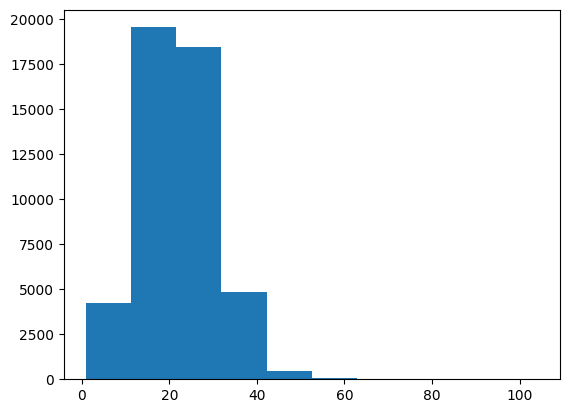

In [ ]:
sent_lengths = [len(sent.split()) for sent in df['Sentence']]
plt.hist(sent_lengths)
plt.show()


The majority of texts contain <= 40 tokens, so we can use this number for padding/truncation.

In [ ]:
tags = [tag for tag_list in df['Tag'] for tag in literal_eval(tag_list)]
tag_counter = Counter(tags)
tags_df = pd.DataFrame({'tag': list(tag_counter.keys()), 'counts': list(tag_counter.values())}).sort_values('counts', ascending=False)

tags_df


,tag,counts
0,O,883124
1,B-geo,37416
7,B-tim,20232
5,B-org,20036
10,I-per,17145
3,B-per,16895
6,I-org,16727
2,B-gpe,15815
4,I-geo,7377
12,I-tim,6496


Well, not great, not terrible. There's a huge imbalance in tags, though it is expected for the task. Anyways, we can expect somewhat poor performance on underrepresented classes.

## Data Preparation

In [ ]:
df['POS'] = df['POS'].apply(literal_eval)
df['Tag'] = df['Tag'].apply(literal_eval)
df['Sentence'] = df['Sentence'].apply(lambda x: re.sub(r"[^\x00-\x7F]", "_", x).split()) # ughhh... yeah, there are non-ASCII symbols, I decided to just replace them


In [ ]:
class Vocab:
    def __init__(self):
        self.word2id = {}
        self.id2word = {}

    def build(self, texts, min_freq=1):
        counter = Counter()
        for text in texts:
            counter.update(text)

        self.word2id['<UNK>'] = 0
        self.id2word[0] = '<UNK>'
        i = 1

        for word, freq in counter.items():
            if freq >= min_freq:
                self.word2id[word] = i
                self.id2word[i] = word
                i += 1

    def __len__(self):
        return len(self.word2id)


In [ ]:
class NERDataset(Dataset):
    def __init__(self, texts, pos_tags, ner_tags, word_vocab, pos_vocab, tag_vocab, sample_len=40):
        self.texts = texts
        self.pos_tags = pos_tags
        self.ner_tags = ner_tags
        self.word_vocab = word_vocab
        self.pos_vocab = pos_vocab
        self.tag_vocab = tag_vocab
        self.sample_len = sample_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        text = self.texts[i]
        pos = self.pos_tags[i]
        ner_tags = self.ner_tags[i]

        if len(text) > self.sample_len:
            text = text[:self.sample_len]
            pos = pos[:self.sample_len]
            ner_tags = ner_tags[:self.sample_len]

        word_ids = [self.word_vocab.word2id.get(word, 0) for word in text]
        pos_ids = [self.pos_vocab.word2id.get(pos_tag, 0) for pos_tag in pos]
        tag_ids = [self.tag_vocab.word2id.get(ner_tag, 0) for ner_tag in ner_tags]

        pad_len = self.sample_len - len(word_ids)
        if pad_len > 0:
            word_ids.extend([0] * pad_len)
            pos_ids.extend([0] * pad_len)
            tag_ids.extend([-100] * pad_len)

        return {
            'words': torch.tensor(word_ids, dtype=torch.long),
            'pos': torch.tensor(pos_ids, dtype=torch.long),
            'tags': torch.tensor(tag_ids, dtype=torch.long),
            'len': len(text)
        }


In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
print(f"train data shape: {train_df.shape}\n"
      f"test data shape: {test_df.shape}\n"
      f"val data shape: {val_df.shape}\n")


train data shape: (30448, 4)
test data shape: (9515, 4)
val data shape: (7612, 4)



In [ ]:
word_vocab = Vocab()
word_vocab.build(train_df['Sentence'], min_freq=2)

pos_vocab = Vocab()
pos_vocab.build(train_df['POS'], min_freq=1)

tag_vocab = Vocab()
tag_vocab.build(train_df['Tag'], min_freq=1)

print(len(word_vocab))
print(len(pos_vocab))
print(len(tag_vocab))


16219
43
18


In [ ]:
train_dset = NERDataset(
    train_df['Sentence'].values,
    train_df['POS'].values,
    train_df['Tag'].values,
    word_vocab, pos_vocab, tag_vocab
)
val_dset = NERDataset(
    val_df['Sentence'].values,
    val_df['POS'].values,
    val_df['Tag'].values,
    word_vocab, pos_vocab, tag_vocab
)
test_dset = NERDataset(
    test_df['Sentence'].values,
    test_df['POS'].values,
    test_df['Tag'].values,
    word_vocab, pos_vocab, tag_vocab
)


In [ ]:
train_loader = DataLoader(train_dset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dset, batch_size=1, shuffle=False)


## Model

Some random model, we'll create separate embeddings for words and POS tags, concat them and process with LSTM. Linear layer for predictions.

In [ ]:
class NERModel(nn.Module):
    def __init__(self, vocab_size, pos_vocab_size, tag_vocab_size, embedding_dim=100, hidden_dim=256, num_layers=2, dropout=0.3):
        super(NERModel, self).__init__()

        self.word_embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(pos_vocab_size, 50, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim + 50,
            hidden_dim, 
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, tag_vocab_size)

    def forward(self, words, pos, lengths=None):
        word_emb = self.word_embedding(words)
        pos_emb = self.pos_embedding(pos)
        combined_emb = torch.cat((word_emb, pos_emb), dim=-1)
        lstm_out, _ = self.lstm(combined_emb)
        lstm_out = self.dropout(lstm_out)
        logits = self.classifier(lstm_out)
        return logits


In [ ]:
model = NERModel(
    vocab_size=len(word_vocab),
    pos_vocab_size=len(pos_vocab),
    tag_vocab_size=len(tag_vocab),
    embedding_dim=100,
    hidden_dim=256
)


## Training

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.001, include_pos=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in trange(num_epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            words = batch['words'].to(device)
            pos = batch['pos'].to(device)
            tags = batch['tags'].to(device)

            optimizer.zero_grad()
            if include_pos is True:
                logits = model(words, pos)
            else:
                logits = model(words)

            loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                words = batch['words'].to(device)
                pos = batch['pos'].to(device)
                tags = batch['tags'].to(device)
                
                if include_pos is True:
                    logits = model(words, pos)
                else:
                    logits = model(words)
                loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


In [ ]:
def plot_training_graph(train_loss, val_loss):
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss', linewidth=2)
    plt.title('График обучения модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


In [ ]:
trained_model, train_losses, val_losses = train_model(model, train_loader, val_loader)


 10%|█         | 1/10 [00:14<02:09, 14.35s/it]

Epoch 1/10
Train Loss: 0.2034, Val Loss: 0.1160


 20%|██        | 2/10 [00:28<01:54, 14.33s/it]

Epoch 2/10
Train Loss: 0.1055, Val Loss: 0.1001


 30%|███       | 3/10 [00:42<01:40, 14.33s/it]

...

Epoch 8/10
Train Loss: 0.0195, Val Loss: 0.1500


 90%|█████████ | 9/10 [02:08<00:14, 14.32s/it]

Epoch 9/10
Train Loss: 0.0151, Val Loss: 0.1629


100%|██████████| 10/10 [02:23<00:00, 14.33s/it]

Epoch 10/10
Train Loss: 0.0122, Val Loss: 0.1738


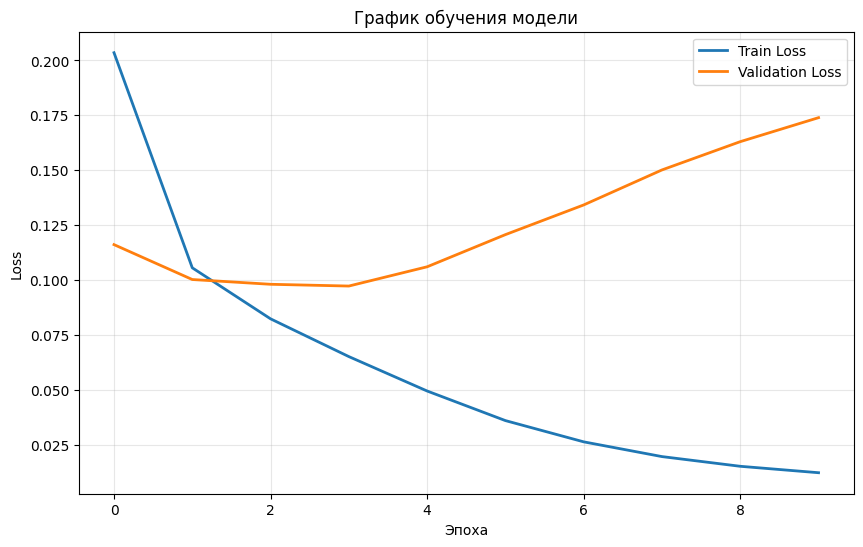

In [ ]:
plot_training_graph(train_losses, val_losses)


In [ ]:
def evaluate_model(model, test_loader, tag_vocab):
    model.eval()
    device = next(model.parameters()).device
    
    all_true = []
    all_pred = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader):
            words = batch['words'].to(device)
            pos = batch['pos'].to(device)
            tags = batch['tags'].to(device)
    
            logits = model(words, pos)
            predictions = torch.argmax(logits, dim=-1)
    
            for i in range(tags.shape[0]):
                length = batch['len'][i]
                true = tags[i][:length].cpu().numpy()
                pred = predictions[i][:length].cpu().numpy()

                all_true.extend(true)
                all_pred.extend(pred)

    true_tags = [tag_vocab.id2word[i] for i in all_true]
    pred_tags = [tag_vocab.id2word[i] for i in all_pred]

    print(classification_report(true_tags, pred_tags, zero_division=0))
    return


In [ ]:
evaluate_model(trained_model, test_loader, tag_vocab)


100%|██████████| 9515/9515 [00:26<00:00, 359.51it/s]


              precision    recall  f1-score   support

       B-art       0.15      0.11      0.13        72
       B-eve       0.40      0.27      0.32        64
       B-geo       0.85      0.90      0.87      7580
       B-gpe       0.95      0.94      0.95      3244
       B-nat       0.41      0.46      0.43        39
       B-org       0.74      0.75      0.74      3951
       B-per       0.84      0.81      0.82      3308
       B-tim       0.89      0.88      0.88      3909
       I-art       0.13      0.16      0.14        44
       I-eve       0.47      0.25      0.33        59
       I-geo       0.80      0.80      0.80      1409
       I-gpe       0.95      0.53      0.68        34
       I-nat       0.25      0.30      0.27        10
       I-org       0.77      0.80      0.79      3322
       I-per       0.85      0.89      0.87      3325
       I-tim       0.80      0.75      0.78      1222
           O       0.99      0.99      0.99    175418

    accuracy              

I'd say it's a pretty good result. With the number of unique tags we have and considering the fact that some classes are underrepresented (and, as expected, they are poorly detected), the performance is quite good. The model doesn't mark all words as 'O', so it should've found some patterns in tagging named entities.

## Weighted Loss

We'll try to improve the result using the weights for classes.

In [ ]:
model_2 = NERModel(
    vocab_size=len(word_vocab),
    pos_vocab_size=len(pos_vocab),
    tag_vocab_size=len(tag_vocab),
    embedding_dim=100,
    hidden_dim=256
)


In [ ]:
class_weights = {}
for tag, count in tag_counter.items():
    class_weights[tag] = tags_df['counts'].sum() / (len(tag_counter) * count)
print(f"Precomputed class weights: {class_weights}")
weights = torch.ones(len(tag_vocab), dtype=torch.float)
for tag, weight in class_weights.items():
    if tag in tag_vocab.word2id:
        i = tag_vocab.word2id[tag]
        weights[i] = weight
print(f"Final class weights: {weights}")


Precomputed class weights: {'O': 0.06947042544421848, 'B-geo': 1.6396995937566816, 'B-gpe': 3.879291811571293, 'B-per': 3.6313110387688665, 'I-geo': 8.316524332384438, 'B-org': 3.0620383310041923, 'I-org': 3.6677826268906557, 'B-tim': 3.0323744563068407, 'B-art': 152.6144278606965, 'I-art': 206.56902356902356, 'I-per': 3.5783610382035578, 'I-gpe': 309.85353535353534, 'I-tim': 9.444427339901479, 'B-nat': 311.4263959390863, 'B-eve': 199.84039087947883, 'I-eve': 243.45634920634922, 'I-nat': 1202.9607843137255}
Final class weights: tensor([1.0000e+00, 6.9470e-02, 1.6397e+00, 3.6313e+00, 3.5784e+00, 3.8793e+00,
        3.0620e+00, 3.0324e+00, 9.4444e+00, 8.3165e+00, 3.6678e+00, 1.9984e+02,
        2.4346e+02, 1.5261e+02, 2.0657e+02, 3.1143e+02, 3.0985e+02, 1.2030e+03])


In [ ]:
def train_model_weighted(model, train_loader, val_loader, class_weights, num_epochs=10, learning_rate=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    class_weights = class_weights.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in trange(num_epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            words = batch['words'].to(device)
            pos = batch['pos'].to(device)
            tags = batch['tags'].to(device)

            optimizer.zero_grad()
            logits = model(words, pos)

            loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                words = batch['words'].to(device)
                pos = batch['pos'].to(device)
                tags = batch['tags'].to(device)
                
                logits = model(words, pos)
                loss = criterion(logits.view(-1, logits.shape[-1]), tags.view(-1))
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


In [ ]:
weighted_model, train_losses, val_losses = train_model_weighted(model, train_loader, val_loader, weights)


 10%|█         | 1/10 [00:13<02:05, 13.98s/it]

Epoch 1/10
Train Loss: 0.1264, Val Loss: 1.4639


 20%|██        | 2/10 [00:27<01:51, 13.96s/it]

Epoch 2/10
Train Loss: 0.0975, Val Loss: 1.4695


 30%|███       | 3/10 [00:41<01:37, 13.95s/it]

...

Epoch 8/10
Train Loss: 0.0229, Val Loss: 2.1013


 90%|█████████ | 9/10 [02:05<00:13, 13.97s/it]

Epoch 9/10
Train Loss: 0.0386, Val Loss: 2.1691


100%|██████████| 10/10 [02:19<00:00, 13.96s/it]

Epoch 10/10
Train Loss: 0.0264, Val Loss: 2.2078


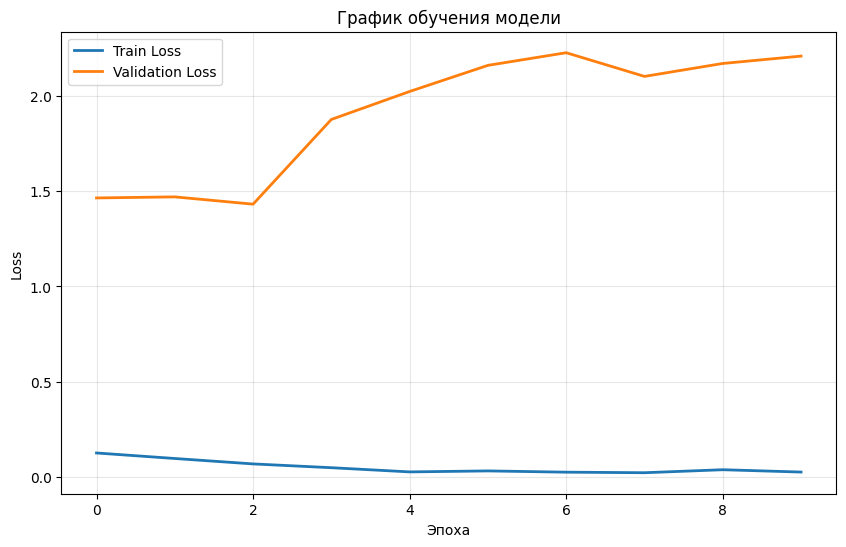

In [ ]:
plot_training_graph(train_losses, val_losses)


Bruh

In [ ]:
evaluate_model(weighted_model, test_loader, tag_vocab)


100%|██████████| 9515/9515 [00:25<00:00, 379.73it/s]


              precision    recall  f1-score   support

       B-art       0.08      0.24      0.12        72
       B-eve       0.19      0.47      0.27        64
       B-geo       0.86      0.85      0.86      7580
       B-gpe       0.93      0.94      0.93      3244
       B-nat       0.28      0.79      0.42        39
       B-org       0.61      0.80      0.69      3951
       B-per       0.78      0.84      0.81      3308
       B-tim       0.69      0.92      0.79      3909
       I-art       0.03      0.05      0.04        44
       I-eve       0.19      0.44      0.26        59
       I-geo       0.67      0.84      0.75      1409
       I-gpe       0.20      0.53      0.29        34
       I-nat       0.32      0.60      0.41        10
       I-org       0.68      0.80      0.74      3322
       I-per       0.83      0.91      0.87      3325
       I-tim       0.53      0.85      0.65      1222
           O       1.00      0.97      0.98    175418

    accuracy              

Well... Weights only made it all worse.

## Simplified Model

For the next step I decided to try a more simple architecture.

In [ ]:
class NERModelSimple(nn.Module):
    def __init__(self, vocab_size, tag_vocab_size, embedding_dim=100, hidden_dim=256, num_layers=2, dropout=0.3):
        super(NERModelSimple, self).__init__()

        self.word_embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim, 
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, tag_vocab_size)

    def forward(self, words, lengths=None):
        word_emb = self.word_embedding(words)
        lstm_out, _ = self.lstm(word_emb)
        lstm_out = self.dropout(lstm_out)
        logits = self.classifier(lstm_out)
        return logits


In [ ]:
simple_model = NERModelSimple(
    vocab_size=len(word_vocab),
    tag_vocab_size=len(tag_vocab),
    embedding_dim=100,
    hidden_dim=256
)


In [ ]:
simple_trained_model, train_losses, val_losses = train_model(simple_model, train_loader, val_loader)


 10%|█         | 1/10 [00:14<02:06, 14.09s/it]

Epoch 1/10
Train Loss: 0.3062, Val Loss: 0.1544


 20%|██        | 2/10 [00:28<01:52, 14.09s/it]

Epoch 2/10
Train Loss: 0.1294, Val Loss: 0.1237


 30%|███       | 3/10 [00:42<01:38, 14.08s/it]

...

Epoch 8/10
Train Loss: 0.0234, Val Loss: 0.1700


 90%|█████████ | 9/10 [02:06<00:14, 14.03s/it]

Epoch 9/10
Train Loss: 0.0183, Val Loss: 0.1852


100%|██████████| 10/10 [02:20<00:00, 14.04s/it]

Epoch 10/10
Train Loss: 0.0143, Val Loss: 0.2004


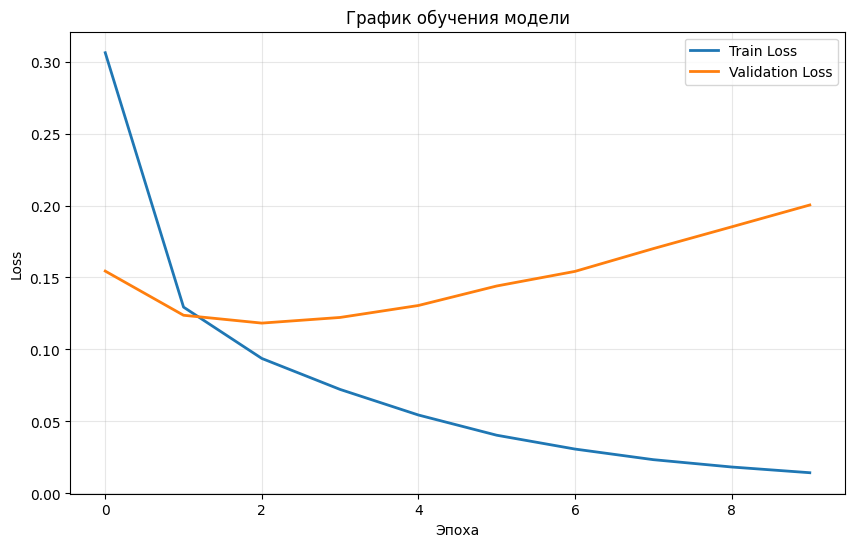

In [ ]:
plot_training_graph(train_losses, val_losses)


In [ ]:
evaluate_model(simple_trained_model, test_loader, tag_vocab)


100%|██████████| 9515/9515 [00:24<00:00, 391.76it/s]


              precision    recall  f1-score   support

       B-art       0.18      0.10      0.13        72
       B-eve       0.35      0.27      0.30        64
       B-geo       0.86      0.86      0.86      7580
       B-gpe       0.95      0.93      0.94      3244
       B-nat       0.61      0.44      0.51        39
       B-org       0.67      0.73      0.70      3951
       B-per       0.83      0.76      0.79      3308
       B-tim       0.90      0.87      0.88      3909
       I-art       0.03      0.02      0.03        44
       I-eve       0.32      0.19      0.24        59
       I-geo       0.79      0.76      0.77      1409
       I-gpe       0.95      0.53      0.68        34
       I-nat       0.67      0.20      0.31        10
       I-org       0.73      0.79      0.76      3322
       I-per       0.85      0.84      0.84      3325
       I-tim       0.78      0.75      0.77      1222
           O       0.99      0.99      0.99    175418

    accuracy              

This model is almost as good as the first one. I guess I should've tried it out first as the most simple variant and count it as baseline, but, well... Anyways, seems like POS tags don't help much here.

## Complicated Model

Let's try adding another LSTM layer and attention mechanism

In [ ]:
class NERModelComp(nn.Module):
    def __init__(self, vocab_size, pos_vocab_size, tag_vocab_size, embedding_dim=100, hidden_dim=256, num_layers=2, dropout=0.3):
        super(NERModelComp, self).__init__()

        self.word_embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(pos_vocab_size, 50, padding_idx=0)
        self.lstm1 = nn.LSTM(
            embedding_dim + 50,
            hidden_dim, 
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.lstm2 = nn.LSTM(
            hidden_dim * 2,
            hidden_dim // 2,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            dropout=dropout,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, tag_vocab_size)

    def forward(self, words, pos, lengths=None):
        word_emb = self.word_embedding(words)
        pos_emb = self.pos_embedding(pos)
        combined_emb = torch.cat((word_emb, pos_emb), dim=-1)
        lstm1_out, _ = self.lstm1(combined_emb)
        lstm2_out, _ = self.lstm2(lstm1_out)
        attn_out, _ = self.attention(lstm2_out, lstm2_out, lstm2_out)
        combined_out = lstm2_out + attn_out
        combined_out = self.dropout(combined_out)
        logits = self.classifier(combined_out)
        return logits


In [ ]:
comp_model = NERModelComp(
    vocab_size=len(word_vocab),
    pos_vocab_size=len(pos_vocab),
    tag_vocab_size=len(tag_vocab),
    embedding_dim=100,
    hidden_dim=256
)


 10%|█         | 1/10 [00:17<02:36, 17.34s/it]

Epoch 1/10
Train Loss: 0.1081, Val Loss: 0.1033


 20%|██        | 2/10 [00:34<02:18, 17.34s/it]

Epoch 2/10
Train Loss: 0.0848, Val Loss: 0.0982


 30%|███       | 3/10 [00:52<02:01, 17.34s/it]

...

Epoch 8/10
Train Loss: 0.0192, Val Loss: 0.1550


 90%|█████████ | 9/10 [02:36<00:17, 17.41s/it]

Epoch 9/10
Train Loss: 0.0152, Val Loss: 0.1629


100%|██████████| 10/10 [02:53<00:00, 17.38s/it]

Epoch 10/10
Train Loss: 0.0126, Val Loss: 0.1737


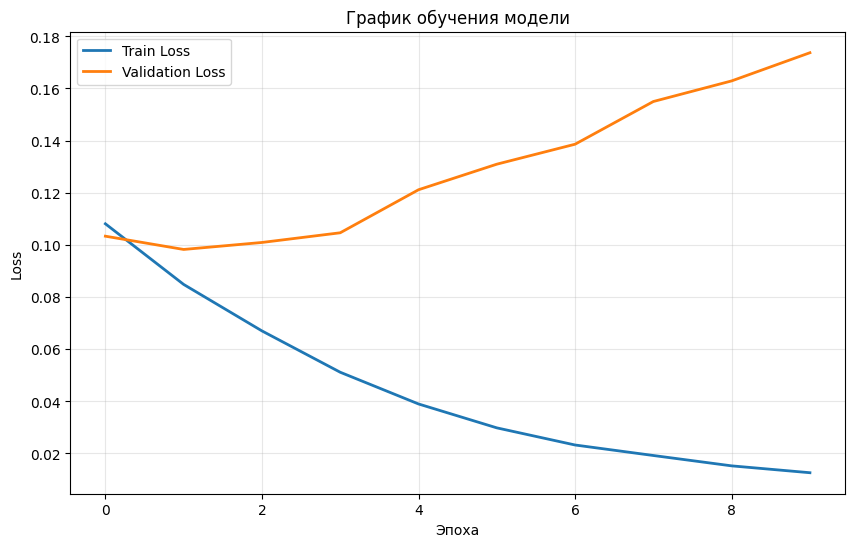

In [ ]:
comp_trained_model, train_losses, val_losses = train_model(comp_model, train_loader, val_loader)
plot_training_graph(train_losses, val_losses)


In [ ]:
evaluate_model(comp_trained_model, test_loader, tag_vocab)


100%|██████████| 9515/9515 [00:31<00:00, 297.55it/s]


              precision    recall  f1-score   support

       B-art       0.14      0.17      0.15        72
       B-eve       0.40      0.31      0.35        64
       B-geo       0.86      0.88      0.87      7580
       B-gpe       0.96      0.93      0.95      3244
       B-nat       0.52      0.41      0.46        39
       B-org       0.73      0.74      0.73      3951
       B-per       0.83      0.82      0.82      3308
       B-tim       0.89      0.89      0.89      3909
       I-art       0.07      0.07      0.07        44
       I-eve       0.38      0.25      0.31        59
       I-geo       0.81      0.78      0.80      1409
       I-gpe       0.70      0.56      0.62        34
       I-nat       0.40      0.20      0.27        10
       I-org       0.77      0.81      0.79      3322
       I-per       0.87      0.86      0.86      3325
       I-tim       0.80      0.76      0.78      1222
           O       0.99      0.99      0.99    175418

    accuracy              

And once again, no improvements. Sadge :(

## Separate Processing Model

Let's try to process words and pos embeddings separately.

In [ ]:
class NERModelSep(nn.Module):
    def __init__(self, vocab_size, pos_vocab_size, tag_vocab_size, word_embed_dim=100, 
                 pos_embed_dim=50, hidden_dim=256, num_layers=2, dropout=0.3):
        super(NERModelSep, self).__init__()
        self.word_embedding = nn.Embedding(vocab_size, word_embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(pos_vocab_size, pos_embed_dim, padding_idx=0)
        self.word_lstm = nn.LSTM(
            word_embed_dim,
            hidden_dim // 2,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.pos_lstm = nn.LSTM(
            pos_embed_dim,
            hidden_dim // 4,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.combiner = nn.Sequential(
            nn.Linear(hidden_dim + hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(hidden_dim, tag_vocab_size)

    def forward(self, words, pos, lengths=None):
        word_emb = self.word_embedding(words)
        pos_emb = self.pos_embedding(pos)
        word_features, _ = self.word_lstm(word_emb)
        pos_features, _ = self.pos_lstm(pos_emb)
        combined = torch.cat([word_features, pos_features], dim=-1)
        combined = self.combiner(combined)
        logits = self.classifier(combined)
        return logits


In [ ]:
sep_model = NERModelSep(
    vocab_size=len(word_vocab),
    pos_vocab_size=len(pos_vocab),
    tag_vocab_size=len(tag_vocab)
)


 10%|█         | 1/10 [00:08<01:12,  8.07s/it]

Epoch 1/10
Train Loss: 0.2428, Val Loss: 0.1214


 20%|██        | 2/10 [00:16<01:04,  8.02s/it]

Epoch 2/10
Train Loss: 0.1111, Val Loss: 0.1044


 30%|███       | 3/10 [00:24<00:55,  7.99s/it]

...

Epoch 8/10
Train Loss: 0.0298, Val Loss: 0.1464


 90%|█████████ | 9/10 [01:11<00:07,  7.97s/it]

Epoch 9/10
Train Loss: 0.0238, Val Loss: 0.1682


100%|██████████| 10/10 [01:19<00:00,  7.98s/it]

Epoch 10/10
Train Loss: 0.0207, Val Loss: 0.1759


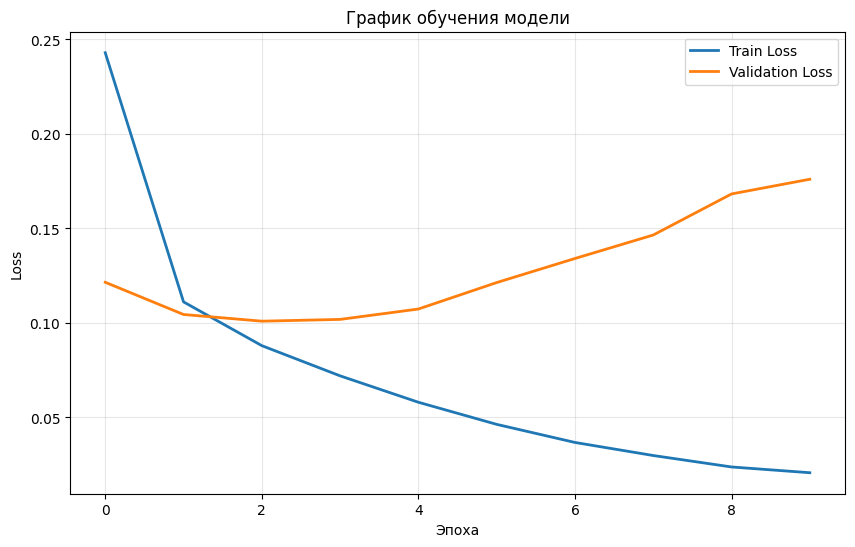

In [ ]:
sep_trained_model, train_losses, val_losses = train_model(sep_model, train_loader, val_loader)
plot_training_graph(train_losses, val_losses)


In [ ]:
evaluate_model(sep_trained_model, test_loader, tag_vocab)


100%|██████████| 9515/9515 [00:19<00:00, 488.11it/s]


              precision    recall  f1-score   support

       B-art       0.14      0.07      0.09        72
       B-eve       0.44      0.25      0.32        64
       B-geo       0.86      0.89      0.87      7580
       B-gpe       0.97      0.94      0.95      3244
       B-nat       0.75      0.23      0.35        39
       B-org       0.73      0.74      0.73      3951
       B-per       0.83      0.81      0.82      3308
       B-tim       0.91      0.87      0.89      3909
       I-art       0.17      0.07      0.10        44
       I-eve       0.35      0.20      0.26        59
       I-geo       0.80      0.79      0.80      1409
       I-gpe       0.81      0.50      0.62        34
       I-nat       0.33      0.10      0.15        10
       I-org       0.80      0.76      0.78      3322
       I-per       0.85      0.88      0.86      3325
       I-tim       0.82      0.76      0.79      1222
           O       0.99      0.99      0.99    175418

    accuracy              

No luck (or skill issue)

Ok, so, experiments with different architectures didn't give any improvements. My guess is that the main problem is the imbalance of classes, as there are very few instances for some tags. We can try to preprocess data a little, at least we can try to change numbers to tags to make our data a little less diverse.

## Normalizing Numbers in Data

In [ ]:
pattern = re.compile(r'\d+(,\d+)*')
df['Sentence'] = df['Sentence'].apply(lambda x: [pattern.sub('<NUM>', word) for word in x])
df.head()


,Sentence #,Sentence,POS,Tag
0,Sentence: 1,"[Thousands, of, demonstrators, have, marched, ...","[NNS, IN, NNS, VBP, VBN, IN, NNP, TO, VB, DT, ...","[O, O, O, O, O, O, B-geo, O, O, O, O, O, B-geo..."
1,Sentence: 2,"[Families, of, soldiers, killed, in, the, conf...","[NNS, IN, NNS, VBN, IN, DT, NN, VBD, DT, NNS, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
2,Sentence: 3,"[They, marched, from, the, Houses, of, Parliam...","[PRP, VBD, IN, DT, NNS, IN, NN, TO, DT, NN, IN...","[O, O, O, O, O, O, O, O, O, O, O, B-geo, I-geo..."
3,Sentence: 4,"[Police, put, the, number, of, marchers, at, <...","[NNS, VBD, DT, NN, IN, NNS, IN, CD, IN, NNS, V...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]"
4,Sentence: 5,"[The, protest, comes, on, the, eve, of, the, a...","[DT, NN, VBZ, IN, DT, NN, IN, DT, JJ, NN, IN, ...","[O, O, O, O, O, O, O, O, O, O, O, B-geo, O, O,..."


In [ ]:
df['Sentence'][3]


['Police',
 'put',
 'the',
 'number',
 'of',
 'marchers',
 'at',
 '<NUM>',
 'while',
 'organizers',
 'claimed',
 'it',
 'was',
 '<NUM>',
 '.']

In [ ]:
train_df_new, test_df_new = train_test_split(df, test_size=0.2, random_state=42)
train_df_new, val_df_new = train_test_split(train_df, test_size=0.2, random_state=42)
print(f"train data shape: {train_df.shape}\n"
      f"test data shape: {test_df.shape}\n"
      f"val data shape: {val_df.shape}\n")


train data shape: (30448, 4)
test data shape: (9515, 4)
val data shape: (7612, 4)



In [ ]:
word_vocab_new = Vocab()
word_vocab_new.build(train_df_new['Sentence'], min_freq=2)

pos_vocab_new = Vocab()
pos_vocab_new.build(train_df_new['POS'], min_freq=1)

tag_vocab_new = Vocab()
tag_vocab_new.build(train_df_new['Tag'], min_freq=1)

print(len(word_vocab_new))
print(len(pos_vocab_new))
print(len(tag_vocab_new))


14451
42
18


In [ ]:
train_dset_new = NERDataset(
    train_df_new['Sentence'].values,
    train_df_new['POS'].values,
    train_df_new['Tag'].values,
    word_vocab_new, pos_vocab_new, tag_vocab_new
)
val_dset_new = NERDataset(
    val_df_new['Sentence'].values,
    val_df_new['POS'].values,
    val_df_new['Tag'].values,
    word_vocab_new, pos_vocab_new, tag_vocab_new
)
test_dset_new = NERDataset(
    test_df_new['Sentence'].values,
    test_df_new['POS'].values,
    test_df_new['Tag'].values,
    word_vocab_new, pos_vocab_new, tag_vocab_new
)


In [ ]:
train_loader_new = DataLoader(train_dset_new, batch_size=32, shuffle=True)
val_loader_new = DataLoader(val_dset_new, batch_size=32, shuffle=False)
test_loader_new = DataLoader(test_dset_new, batch_size=1, shuffle=False)


### Model

In [ ]:
model_new = NERModel(
    vocab_size=len(word_vocab),
    pos_vocab_size=len(pos_vocab),
    tag_vocab_size=len(tag_vocab),
    embedding_dim=100,
    hidden_dim=256
)


 10%|█         | 1/10 [00:11<01:41, 11.24s/it]

Epoch 1/10
Train Loss: 0.2279, Val Loss: 0.1264


 20%|██        | 2/10 [00:22<01:29, 11.25s/it]

Epoch 2/10
Train Loss: 0.1123, Val Loss: 0.1091


 30%|███       | 3/10 [00:33<01:18, 11.25s/it]

...

Epoch 8/10
Train Loss: 0.0210, Val Loss: 0.1626


 90%|█████████ | 9/10 [01:41<00:11, 11.25s/it]

Epoch 9/10
Train Loss: 0.0146, Val Loss: 0.1794


100%|██████████| 10/10 [01:52<00:00, 11.25s/it]

Epoch 10/10
Train Loss: 0.0113, Val Loss: 0.1953


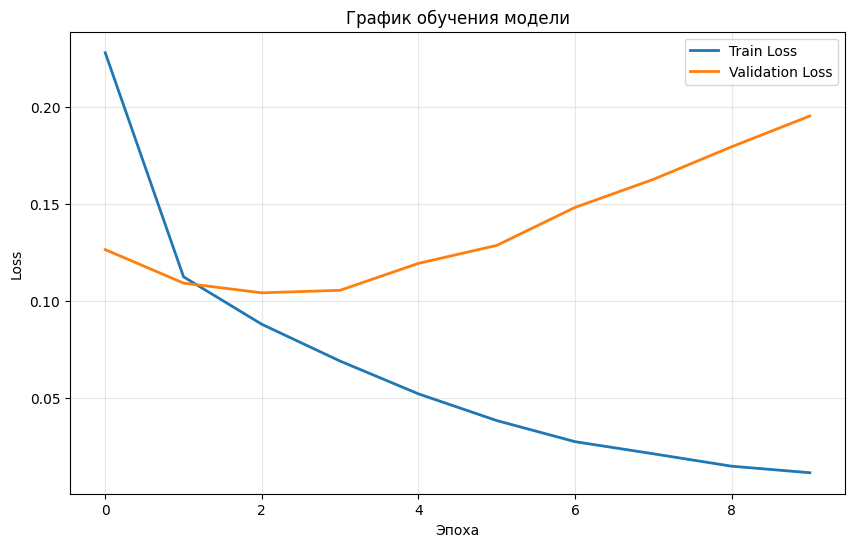

In [ ]:
trained_model_new, train_losses, val_losses = train_model(model_new, train_loader_new, val_loader_new)
plot_training_graph(train_losses, val_losses)


In [ ]:
evaluate_model(trained_model_new, test_loader_new, tag_vocab_new)


100%|██████████| 9515/9515 [00:24<00:00, 382.33it/s]


              precision    recall  f1-score   support

       B-art       0.08      0.06      0.07        72
       B-eve       0.27      0.22      0.24        64
       B-geo       0.87      0.88      0.87      7580
       B-gpe       0.97      0.93      0.95      3244
       B-nat       0.50      0.33      0.40        39
       B-org       0.71      0.74      0.73      3951
       B-per       0.82      0.80      0.81      3308
       B-tim       0.89      0.85      0.87      3909
       I-art       0.00      0.00      0.00        44
       I-eve       0.36      0.27      0.31        59
       I-geo       0.81      0.78      0.80      1409
       I-gpe       0.75      0.53      0.62        34
       I-nat       0.25      0.30      0.27        10
       I-org       0.78      0.77      0.78      3322
       I-per       0.85      0.87      0.86      3325
       I-tim       0.85      0.69      0.76      1222
           O       0.99      0.99      0.99    175418

    accuracy              

And... no, no improvements.

After conducting these experiments we see that we couldn't get better results than with the first model. Perhaps it's maximum (or nearly maximum) of what could be done with LSTM models. Perhaps, transformer would work better here. In my opinion, the main problem here is the imbalance of classes as from classification reports we can clearly see that all tags that have more than 1000 occurrences are defined correctly in the most cases.

## Saving Best Model

In [ ]:
model_path = 'ner_model.pth'


In [ ]:
checkpoint = {
    'model_state_dict': trained_model.state_dict(),
    
    'word_vocab': word_vocab.word2id,
    'pos_vocab': pos_vocab.word2id, 
    'tag_vocab': tag_vocab.word2id,
    
    'model_config': {
        'vocab_size': len(word_vocab),
        'pos_vocab_size': len(pos_vocab),
        'tag_vocab_size': len(tag_vocab),
        'embedding_dim': trained_model.word_embedding.embedding_dim,
        'hidden_dim': trained_model.lstm.hidden_size,
        'num_layers': trained_model.lstm.num_layers,
        'dropout': trained_model.dropout.p
    }
}
torch.save(checkpoint, model_path)


In [ ]:
def load_model(filepath, device='cpu'):
    checkpoint = torch.load(filepath, map_location=device)

    word_vocab = Vocab()
    word_vocab.word2id = checkpoint['word_vocab']
    word_vocab.id2word = {v: k for k, v in checkpoint['word_vocab'].items()}

    pos_vocab = Vocab()
    pos_vocab.word2id = checkpoint['pos_vocab']
    pos_vocab.id2word = {v: k for k, v in checkpoint['pos_vocab'].items()}

    tag_vocab = Vocab()
    tag_vocab.word2id = checkpoint['tag_vocab']
    tag_vocab.id2word = {v: k for k, v in checkpoint['tag_vocab'].items()}

    config = checkpoint['model_config']
    model = NERModel(
        vocab_size=config['vocab_size'],
        pos_vocab_size=config['pos_vocab_size'],
        tag_vocab_size=config['tag_vocab_size'],
        embedding_dim=config['embedding_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config.get('num_layers', 2),
        dropout=config.get('dropout', 0.3)
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    print('Model loaded successfully!')
    return model, word_vocab, pos_vocab, tag_vocab


In [ ]:
loaded_model, loaded_word_vocab, loaded_pos_vocab, loaded_tag_vocab = load_model(model_path, 'cuda')


Model loaded successfully!
